## Задача 3. Сравнение методов классификации

### Васаулюа Брюнотт Тази  М81

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
custom_colors = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"]
import warnings
from sklearn.base import BaseEstimator
warnings.filterwarnings('ignore')

Самостоятельно реализовать один из методов классификации, с возможностью настройки гиперпараметров.

- SVM

- Logistic Regression

In [33]:
# class LogisticRegressionClassifier(BaseEstimator):
#     def __init__(self, learning_rate=0.01, num_iter=1000, regularization_strength=0.01):
#         """
#         Initialize Logistic Regression with learning rate, number of iterations, 
#         and L2 regularization strength.
#         """
#         self.learning_rate = learning_rate
#         self.num_iter = num_iter
#         self.regularization_strength = regularization_strength
#         self.weights = None
#         self.bias = 0

#     def _sigmoid(self, z):
#         """Apply the sigmoid function."""
#         return 1 / (1 + np.exp(-z))

#     def _initialize_weights(self, n_features):
#         """Initialize weights to small random values."""
#         self.weights = np.random.rand(n_features) * 0.01
#         self.bias = 0

#     def _add_regularization(self, dw):
#         """Apply L2 regularization to weight gradients."""
#         return dw + self.regularization_strength * self.weights

#     def fit(self, X, y):
#         """
#         Fit the model to the data using gradient descent.
#         """
#         # Feature scaling
#         X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
        
#         n_samples, n_features = X.shape
#         self._initialize_weights(n_features)

#         # Gradient descent
#         for i in range(self.num_iter):
#             # Linear model prediction
#             linear_model = np.dot(X, self.weights) + self.bias
#             y_pred = self._sigmoid(linear_model)

#             # Gradient computation
#             dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
#             db = (1 / n_samples) * np.sum(y_pred - y)
            
#             # Apply regularization to gradients
#             dw = self._add_regularization(dw)

#             # Update weights and bias
#             self.weights -= self.learning_rate * dw
#             self.bias -= self.learning_rate * db

#         return self

#     def predict_proba(self, X):
#         """
#         Predict probability estimates for X.
#         """
#         X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)  # Feature scaling for input data
#         linear_model = np.dot(X, self.weights) + self.bias
#         return self._sigmoid(linear_model)

#     def predict(self, X):
#         """
#         Predict binary class labels for samples in X.
#         """
#         proba = self.predict_proba(X)
#         return np.where(proba >= 0.5, 1, 0)

#     def get_params(self, deep=True):
#         """
#         Return the parameters of the estimator.
#         """
#         return {'learning_rate': self.learning_rate, 'num_iter': self.num_iter,
#                 'regularization_strength': self.regularization_strength}

#     def set_params(self, **parameters):
#         """
#         Set the parameters of the estimator.
#         """
#         for param, value in parameters.items():
#             setattr(self, param, value)
#         return self

from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
from sklearn.model_selection import GridSearchCV

class LogisticRegressionClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, learning_rate=0.01, num_iter=1000, regularization_strength=0.01):
        """
        Initialize Logistic Regression with learning rate, number of iterations, 
        and L2 regularization strength.
        """
        self.learning_rate = learning_rate
        self.num_iter = num_iter
        self.regularization_strength = regularization_strength
        self.weights = None
        self.bias = 0

    def _sigmoid(self, z):
        """Apply the sigmoid function."""
        return 1 / (1 + np.exp(-z))

    def _initialize_weights(self, n_features):
        """Initialize weights to small random values."""
        self.weights = np.random.rand(n_features) * 0.01
        self.bias = 0

    def _add_regularization(self, dw):
        """Apply L2 regularization to weight gradients."""
        return dw + self.regularization_strength * self.weights

    def fit(self, X, y):
        """
        Fit the model to the data using gradient descent.
        """
        # Feature scaling
        X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
        
        n_samples, n_features = X.shape
        self._initialize_weights(n_features)

        # Gradient descent
        for i in range(self.num_iter):
            # Linear model prediction
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear_model)

            # Gradient computation
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            # Apply regularization to gradients
            dw = self._add_regularization(dw)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        return self

    def predict_proba(self, X):
        """
        Predict probability estimates for X.
        """
        X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)  # Feature scaling for input data
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X):
        """
        Predict binary class labels for samples in X.
        """
        proba = self.predict_proba(X)
        return np.where(proba >= 0.5, 1, 0)

    def score(self, X, y):
        """
        Return the mean accuracy on the given test data and labels.
        """
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

    def get_params(self, deep=True):
        """
        Return the parameters of the estimator.
        """
        return {'learning_rate': self.learning_rate, 
                'num_iter': self.num_iter,
                'regularization_strength': self.regularization_strength}

    def set_params(self, **parameters):
        """
        Set the parameters of the estimator.
        """
        for param, value in parameters.items():
            setattr(self, param, value)
        return self

# # Example usage with GridSearchCV
# from sklearn.datasets import make_classification
# from sklearn.model_selection import train_test_split

# # Create a sample dataset
# X, y = make_classification(n_samples=100, n_features=20, n_classes=2, random_state=42)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Define the parameter grid
# param_grid = {
#     'learning_rate': [0.001, 0.01, 0.1],
#     'num_iter': [500, 1000, 1500],
#     'regularization_strength': [0.01, 0.1, 1]
# }

# # Initialize the LogisticRegressionClassifier
# log_reg = LogisticRegressionClassifier()

# # Initialize GridSearchCV
# grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, scoring='accuracy', cv=5)

# # Fit GridSearchCV
# grid_search.fit(X_train, y_train)

# # Print the best score and best parameters
# print("Best Score:", grid_search.best_score_)
# print("Best Parameters :", grid_search.best_params_)

In [34]:

# class SVMClassifier(BaseEstimator):
#     def __init__(self, C=1.0, kernel='linear', degree=3, gamma=0.1, coef0=1.0, max_iter=100, tol=1e-3):
#         self.C = C
#         self.kernel = kernel
#         self.degree = degree
#         self.gamma = gamma
#         self.coef0 = coef0
#         self.max_iter = max_iter
#         self.tol = tol
#         self.alpha = None
#         self.weights = None
#         self.bias = 0
#         self.X_train = None  # Store training data for prediction
#         self.y_train = None  # Store training labels

#     def _kernel_function(self, x1, x2):
#         if self.kernel == 'linear':
#             return np.dot(x1, x2)
#         elif self.kernel == 'polynomial':
#             return (self.gamma * np.dot(x1, x2) + self.coef0) ** self.degree
#         elif self.kernel == 'rbf':
#             return np.exp(-self.gamma * np.linalg.norm(x1 - x2) ** 2)
#         else:
#             raise ValueError(f"Unsupported kernel '{self.kernel}'")

#     def fit(self, X, y):
#         # Ensure X and y are numpy arrays to prevent KeyError issues with pandas
#         X = np.array(X)  # Convert X to numpy array
#         y = np.array(y)  # Convert y to numpy array
#         self.X_train = X  # Store training data for prediction
#         self.y_train = np.where(y <= 0, -1, 1)  # Store converted training labels
        
#         n_samples, n_features = X.shape
#         self.alpha = np.zeros(n_samples)

#         # Compute the kernel matrix
#         K = np.zeros((n_samples, n_samples))
#         for i in range(n_samples):
#             for j in range(n_samples):
#                 K[i, j] = self._kernel_function(X[i], X[j])

#         # Dual optimization using coordinate descent
#         for _ in range(self.max_iter):
#             alpha_prev = np.copy(self.alpha)
#             for i in range(n_samples):
#                 # Calculate the margin
#                 margin = y[i] * (np.sum(self.alpha * y * K[:, i]) - self.bias)

#                 # Update alpha[i] based on the SVM conditions
#                 if margin < 1:
#                     self.alpha[i] += self.C * (1 - margin)
#                 else:
#                     self.alpha[i] *= (1 - self.C)

#             # Check for convergence (change in alpha < tolerance)
#             if np.linalg.norm(self.alpha - alpha_prev) < self.tol:
#                 break

#         # Compute weights and bias
#         if self.kernel == 'linear':
#             self.weights = np.sum((self.alpha * y)[:, np.newaxis] * X, axis=0)

#         # Calculate bias using support vectors
#         support_indices = np.where((self.alpha > 1e-4) & (self.alpha < self.C))[0]
#         self.bias = np.mean([y[i] - np.sum(self.alpha * y * K[i]) for i in support_indices])

#         return self

#     def predict(self, X):
#         X = np.array(X)  # Ensure X is a numpy array
#         # For non-linear kernel predictions, use the support vector representation
#         decision = np.array([
#             np.sum(self.alpha * self.y_train * np.array([self._kernel_function(x, xi) for xi in self.X_train]))
#             for x in X
#         ]) + self.bias
#         return np.where(decision >= 0, 1, 0)


from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
from sklearn.model_selection import GridSearchCV

class SVMClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, C=1.0, kernel='linear', degree=3, gamma=0.1, coef0=1.0, max_iter=100, tol=1e-3):
        self.C = C
        self.kernel = kernel
        self.degree = degree
        self.gamma = gamma
        self.coef0 = coef0
        self.max_iter = max_iter
        self.tol = tol
        self.alpha = None
        self.weights = None
        self.bias = 0
        self.X_train = None  # Store training data for prediction
        self.y_train = None  # Store training labels

    def _kernel_function(self, x1, x2):
        if self.kernel == 'linear':
            return np.dot(x1, x2)
        elif self.kernel == 'polynomial':
            return (self.gamma * np.dot(x1, x2) + self.coef0) ** self.degree
        elif self.kernel == 'rbf':
            return np.exp(-self.gamma * np.linalg.norm(x1 - x2) ** 2)
        else:
            raise ValueError(f"Unsupported kernel '{self.kernel}'")

    def fit(self, X, y):
        X = np.array(X)  # Convert X to numpy array
        y = np.array(y)  # Convert y to numpy array
        self.X_train = X  # Store training data for prediction
        self.y_train = np.where(y <= 0, -1, 1)  # Store converted training labels
        
        n_samples, n_features = X.shape
        self.alpha = np.zeros(n_samples)

        # Compute the kernel matrix
        K = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                K[i, j] = self._kernel_function(X[i], X[j])

        # Dual optimization using coordinate descent
        for _ in range(self.max_iter):
            alpha_prev = np.copy(self.alpha)
            for i in range(n_samples):
                # Calculate the margin
                margin = y[i] * (np.sum(self.alpha * y * K[:, i]) - self.bias)

                # Update alpha[i] based on the SVM conditions
                if margin < 1:
                    self.alpha[i] += self.C * (1 - margin)
                else:
                    self.alpha[i] *= (1 - self.C)

            # Check for convergence (change in alpha < tolerance)
            if np.linalg.norm(self.alpha - alpha_prev) < self.tol:
                break

        # Compute weights and bias
        if self.kernel == 'linear':
            self.weights = np.sum((self.alpha * y)[:, np.newaxis] * X, axis=0)

        # Calculate bias using support vectors
        support_indices = np.where((self.alpha > 1e-4) & (self.alpha < self.C))[0]
        self.bias = np.mean([y[i] - np.sum(self.alpha * y * K[i]) for i in support_indices])

        return self

    def predict(self, X):
        X = np.array(X)  # Ensure X is a numpy array
        decision = np.array([
            np.sum(self.alpha * self.y_train * np.array([self._kernel_function(x, xi) for xi in self.X_train]))
            for x in X
        ]) + self.bias
        return np.where(decision >= 0, 1, 0)

    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

    def get_params(self, deep=True):
        return {
            'C': self.C,
            'kernel': self.kernel,
            'degree': self.degree,
            'gamma': self.gamma,
            'coef0': self.coef0,
            'max_iter': self.max_iter,
            'tol': self.tol
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self


# # Define the parameter grid
# param_grid = {
#     'C': [0.1, 1, 10],
#     'kernel': ['linear', 'rbf'],
#     'gamma': [0.01, 0.1, 1]
# }

# # Initialize the SVMClassifier
# svm = SVMClassifier()

# # Initialize GridSearchCV
# grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, scoring='accuracy', cv=5)

# # Fit GridSearchCV
# grid_search.fit(X_train, y_train)

# # Print the best score and best parameters
# print("Best Score:", grid_search.best_score_)
# print("Best Parameters:", grid_search.best_params_) ```python
# from sklearn.base import BaseEstimator, ClassifierMixin
# import numpy as np
# from sklearn.model_selection import GridSearchCV

# class SVMClassifier(BaseEstimator, ClassifierMixin):
#     def __init__(self, C=1.0, kernel='linear', degree=3, gamma=0.1, coef0=1.0, max_iter=100, tol=1e-3):
#         self.C = C
#         self.kernel = kernel
#         self.degree = degree
#         self.gamma = gamma
#         self.coef0 = coef0
#         self.max_iter = max_iter
#         self.tol = tol
#         self.alpha = None
#         self.weights = None
#         self.bias = 0
#         self.X_train = None  # Store training data for prediction
#         self.y_train = None  # Store training labels

#     def _kernel_function(self, x1, x2):
#         if self.kernel == 'linear':
#             return np.dot(x1, x2)
#         elif self.kernel == 'polynomial':
#             return (self.gamma * np.dot(x1, x2) + self.coef0) ** self.degree
#         elif self.kernel == 'rbf':
#             return np.exp(-self.gamma * np.linalg.norm(x1 - x2) ** 2)
#         else:
#             raise ValueError(f"Unsupported kernel '{self.kernel}'")

#     def fit(self, X, y):
#         X = np.array(X)  # Convert X to numpy array
#         y = np.array(y)  # Convert y to numpy array
#         self.X_train = X  # Store training data for prediction
#         self.y_train = np.where(y <= 0, -1, 1)  # Store converted training labels
        
#         n_samples, n_features = X.shape
#         self.alpha = np.zeros(n_samples)

#         # Compute the kernel matrix
#         K = np.zeros((n_samples, n_samples))
#         for i in range(n_samples):
#             for j in range(n_samples):
#                 K[i, j] = self._kernel_function(X[i], X[j])

#         # Dual optimization using coordinate descent
#         for _ in range(self.max_iter):
#             alpha_prev = np.copy(self.alpha)
#             for i in range(n_samples):
#                 # Calculate the margin
#                 margin = y[i] * (np.sum(self.alpha * y * K[:, i]) - self.bias)

#                 # Update alpha[i] based on the SVM conditions
#                 if margin < 1:
#                     self.alpha[i] += self.C * (1 - margin)
#                 else:
#                     self.alpha[i] *= (1 - self.C)

#             # Check for convergence (change in alpha < tolerance)
#             if np.linalg.norm(self.alpha - alpha_prev) < self.tol:
#                 break

#         # Compute weights and bias
#         if self.kernel == 'linear':
#             self.weights = np.sum((self.alpha * y)[:, np.newaxis] * X, axis=0)

#         # Calculate bias using support vectors
#         support_indices = np.where((self.alpha > 1e-4) & (self.alpha < self.C))[0]
#         self.bias = np.mean([y[i] - np.sum(self.alpha * y * K[i]) for i in support_indices])

#         return self

#     def predict(self, X):
#         X = np.array(X)  # Ensure X is a numpy array
#         decision = np.array([
#             np.sum(self.alpha * self.y_train * np.array([self._kernel_function(x, xi) for xi in self.X_train]))
#             for x in X
#         ]) + self.bias
#         return np.where(decision >= 0, 1, 0)

#     def score(self, X, y):
#         y_pred = self.predict(X)
#         return np.mean(y_pred == y)

#     def get_params(self, deep=True):
#         return {
#             'C': self.C,
#             'kernel': self.kernel,
#             'degree': self.degree,
#             'gamma': self.gamma,
#             'coef0': self.coef0,
#             'max_iter': self.max_iter,
#             'tol': self.tol
#         }

#     def set_params(self, **params):
#         for key, value in params.items():
#             setattr(self, key, value)
#         return self

# # Example usage with GridSearchCV
# from sklearn.datasets import make_classification
# from sklearn.model_selection import train_test_split

# # Create a sample dataset
# X, y = make_classification(n_samples=100, n_features=20, n_classes=2, random_state=42)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Define the parameter grid
# param_grid = {
#     'C': [0. 1, 1, 10],
#     'kernel': ['linear', 'rbf'],
#     'gamma': [0.01, 0.1, 1]
# }

# # Initialize the SVMClassifier
# svm = SVMClassifier()

# # Initialize GridSearchCV
# grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, scoring='accuracy', cv=5)

# # Fit GridSearchCV
# grid_search.fit(X_train, y_train)

# # Print the best score and best parameters
# print("Best Score:", grid_search.best_score_)
# print("Best Parameters:", grid_search.best_params_)

Взять данные для предсказания заболеваний сердца [тут](https://github.com/rustam-azimov/ml-course/tree/main/data/heart_disease) (целевой признак для предсказания --- **target**). Демо блокнот с анализом этих данных можно найти [тут](https://github.com/rustam-azimov/ml-course/blob/main/practice/practice07_knn_nb/practice07_part02_classification_heart_disease_demo.ipynb).

- Считать данные, выполнить первичный анализ данных, при необходимости произвести чистку данных (**Data Cleaning**).
- Выполнить разведочный анализ (**EDA**), использовать визуализацию, сделать выводы, которые могут быть полезны при дальнейшем решении задачи классификации.
- При необходимости выполнить полезные преобразования данных (например, трансформировать категариальные признаки в количественные), убрать ненужные признаки, создать новые (**Feature Engineering**).

In [35]:
df = pd.read_csv(r"data\heart_disease\heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


Описание датасета:
- age - age in years
- sex - (1 = male; 0 = female)
- cp - chest pain type
- trestbps - resting blood pressure (in mm Hg on admission to the hospital)
- chol - serum cholestoral in mg/dl
- fbs - (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
- restecg - resting electrocardiographic results
- thalach - maximum heart rate achieved
- exang - exercise induced angina (1 = yes; 0 = no)
- oldpeak - ST depression induced by exercise relative to rest
- slope - the slope of the peak exercise ST segment
- ca - number of major vessels (0-3) colored by flourosopy
- thal - 3 = normal; 6 = fixed defect; 7 = reversable defect
- target - have disease or not (1=yes, 0=no)
#### Необходимо решить задачу классификации и научиться предсказывать целовой признак target (имеет ли пациент заболевание сердца).

In [36]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## EDA

<Axes: xlabel='target', ylabel='count'>

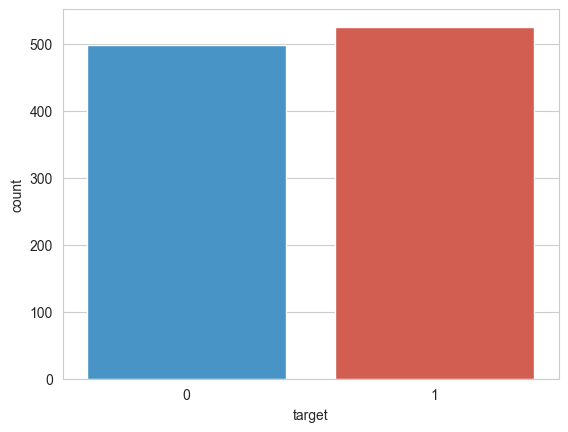

In [38]:
sns.countplot(x="target", data=df, palette=custom_colors)

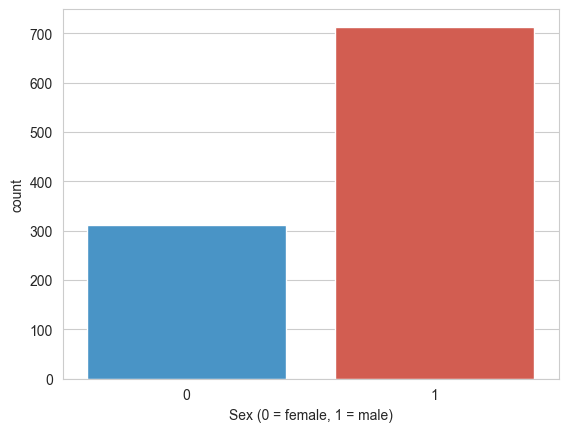

In [39]:
sns.countplot(x='sex', data=df, palette=custom_colors)
plt.xlabel("Sex (0 = female, 1 = male)")
plt.show()

Датасет содержит больше данных пациентов мужского пола.

In [40]:

df.groupby('target').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.569138,0.827655,0.482966,134.106212,251.292585,0.164329,0.456914,139.130261,0.549098,1.600200,1.166333,1.158317,2.539078
1,52.408745,0.570342,1.378327,129.245247,240.979087,0.134981,0.598859,158.585551,0.134981,0.569962,1.593156,0.370722,2.119772


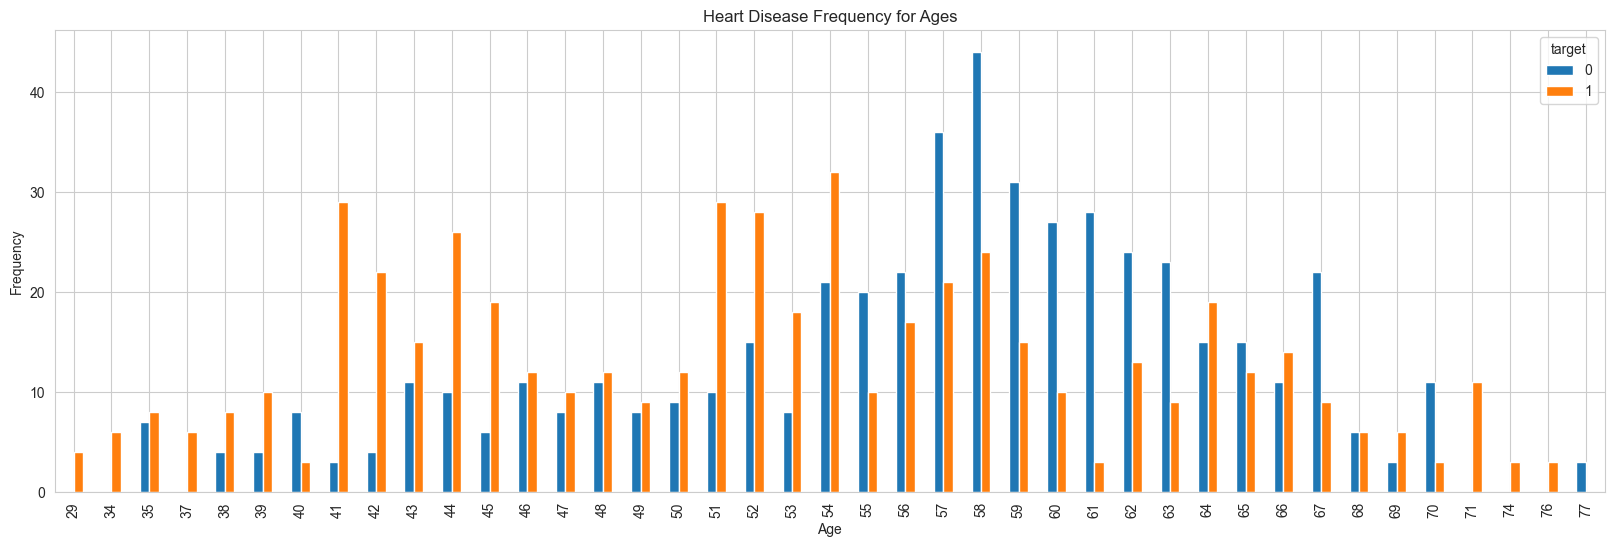

In [41]:
pd.crosstab(df.age,df.target).plot(kind="bar", figsize=(20, 6))
plt.title('Heart Disease Frequency for Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

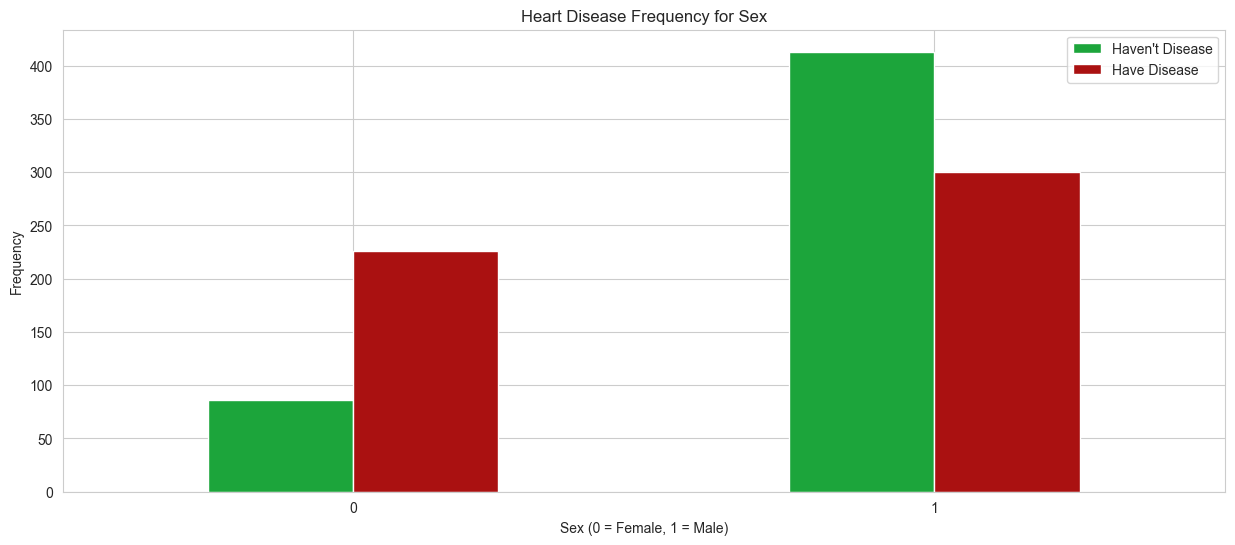

In [42]:
pd.crosstab(df.sex,df.target).plot(kind="bar", figsize=(15, 6), color=['#1CA53B', '#AA1111' ])
plt.title('Heart Disease Frequency for Sex')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.xticks(rotation=0)
plt.legend(["Haven't Disease", "Have Disease"])
plt.ylabel('Frequency')
plt.show()

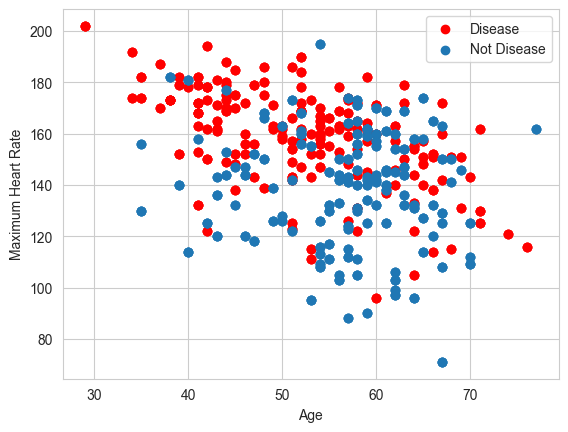

In [43]:
plt.scatter(x=df.age[df.target==1], y=df.thalach[(df.target==1)], c="red")
plt.scatter(x=df.age[df.target==0], y=df.thalach[(df.target==0)])
plt.legend(["Disease", "Not Disease"])
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")
plt.show()

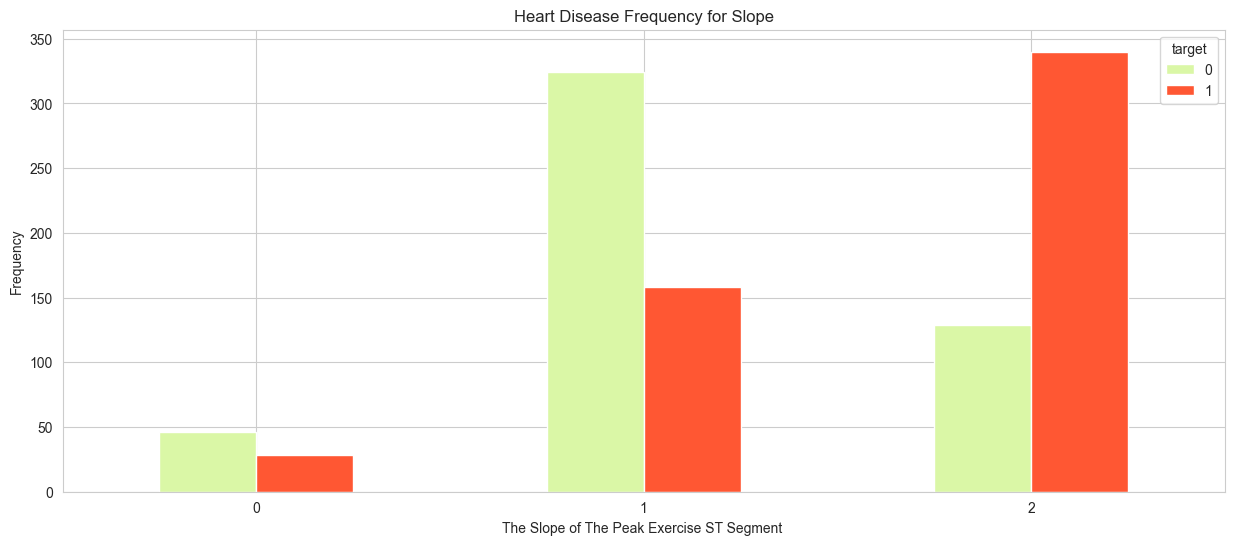

In [44]:
pd.crosstab(df.slope,df.target).plot(kind="bar", figsize=(15, 6), color=['#DAF7A6','#FF5733' ])
plt.title('Heart Disease Frequency for Slope')
plt.xlabel('The Slope of The Peak Exercise ST Segment ')
plt.xticks(rotation = 0)
plt.ylabel('Frequency')
plt.show()

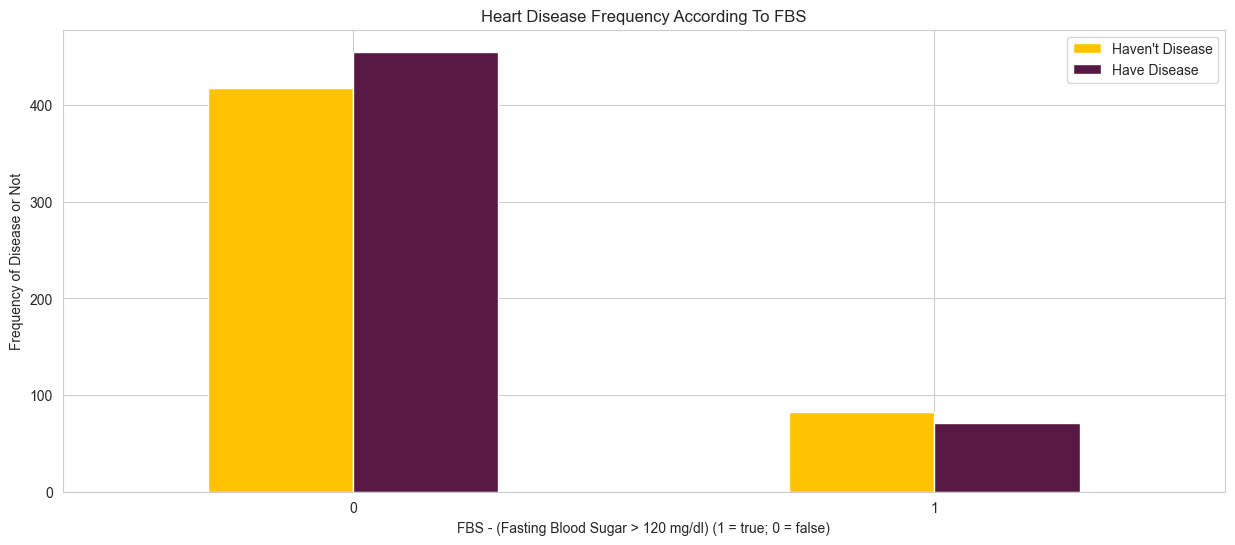

In [45]:
pd.crosstab(df.fbs,df.target).plot(kind="bar", figsize=(15, 6), color=['#FFC300','#581845' ])
plt.title('Heart Disease Frequency According To FBS')
plt.xlabel('FBS - (Fasting Blood Sugar > 120 mg/dl) (1 = true; 0 = false)')
plt.xticks(rotation = 0)
plt.legend(["Haven't Disease", "Have Disease"])
plt.ylabel('Frequency of Disease or Not')
plt.show()

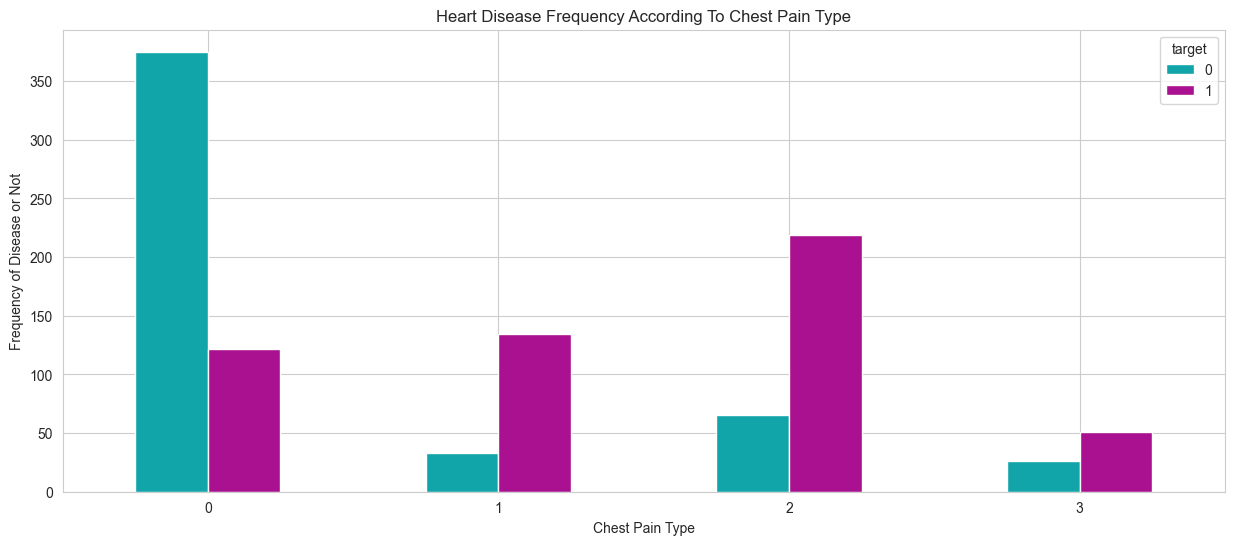

In [46]:
pd.crosstab(df.cp,df.target).plot(kind="bar",figsize=(15, 6), color=['#11A5AA','#AA1190' ])
plt.title('Heart Disease Frequency According To Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.xticks(rotation = 0)
plt.ylabel('Frequency of Disease or Not')
plt.show()

### Преобразование категориальных признаков

In [47]:
cp_dum = pd.get_dummies(df['cp'], prefix = "cp")
thal_dum = pd.get_dummies(df['thal'], prefix = "thal")
slope_dum = pd.get_dummies(df['slope'], prefix = "slope")

frames = [df, cp_dum, thal_dum, slope_dum]
df = pd.concat(frames, axis = 1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3,slope_0,slope_1,slope_2
0,52,1,0,125,212,0,1,168,0,1.0,...,False,False,False,False,False,False,True,False,False,True
1,53,1,0,140,203,1,0,155,1,3.1,...,False,False,False,False,False,False,True,True,False,False
2,70,1,0,145,174,0,1,125,1,2.6,...,False,False,False,False,False,False,True,True,False,False
3,61,1,0,148,203,0,1,161,0,0.0,...,False,False,False,False,False,False,True,False,False,True
4,62,0,0,138,294,1,1,106,0,1.9,...,False,False,False,False,False,True,False,False,True,False


In [48]:
df = df.drop(columns = ['cp', 'thal', 'slope'])
df.head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,...,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3,slope_0,slope_1,slope_2
0,52,1,125,212,0,1,168,0,1.0,2,...,False,False,False,False,False,False,True,False,False,True
1,53,1,140,203,1,0,155,1,3.1,0,...,False,False,False,False,False,False,True,True,False,False
2,70,1,145,174,0,1,125,1,2.6,0,...,False,False,False,False,False,False,True,True,False,False
3,61,1,148,203,0,1,161,0,0.0,1,...,False,False,False,False,False,False,True,False,False,True
4,62,0,138,294,1,1,106,0,1.9,3,...,False,False,False,False,False,True,False,False,True,False


Используя **подбор гиперпараметров**, **кросс-валидацию** и при необходимости **масштабирование данных**, добиться наилучшего качества предсказания от Вашей реализации на выделенной заранее тестовой выборке.

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

y = df['target']
X = df.drop(columns=['target'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=37)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Повторить предыдущий пункт для библиотечных реализаций (например, из **sklearn**) всех пройденных методов классификации (**logistic regression, svm, knn, naive bayes, decision tree**).
Сравнить все обученные модели, построить их **confusion matrices**. Сделать выводы о полученных моделях в рамках решения задачи классификации на выбранных данных.

In [50]:
# # Assuming X_train, X_test, y_train, y_test are available
# from sklearn.metrics import accuracy_score

# # Instantiate with RBF kernel
# svm = SVMClassifier(C=1.0, kernel='rbf', gamma=0.1, max_iter=100, tol=1e-3)
# svm.fit(X_train, y_train)
# predictions = svm.predict(X_test)

# # Evaluate accuracy
# accuracy = accuracy_score(y_test, predictions)
# print("Accuracy:", accuracy)


In [ ]:

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 0.01, 0.25, 2, 1, 5, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': [0.0001, 0.01, 0.1, 1,"auto", "scale"]
}

# Initialize the SVMClassifier
svm = SVMClassifier()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, scoring='accuracy', cv=5)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)
best_my_svc= grid_search.best_estimator_
# Print the best score and best parameters
print("Best Score:", grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

In [ ]:
from sklearn.svm import SVC

svc = SVC(random_state=37)

C_grid = [0.1, 0.25, 0.5, 0.75, 1, 2]
kernel_grid = ["linear", "rbf"]
gamma_grid = ["scale", "auto", 1e-4, 1e-3, 1e-2, 1e-1, 1]

searcher = GridSearchCV(svc, {'C': C_grid, 'kernel': kernel_grid, 'gamma': gamma_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_svc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'C': 0.5, 'gamma': 1, 'kernel': 'rbf'}
Best score:  0.9554001554001553


In [ ]:
# # Assuming X_train, X_test, y_train, y_test are available
# from sklearn.metrics import accuracy_score

# # Instantiate the logistic regression model
# log_reg = LogisticRegressionClassifier(learning_rate=0.01, num_iter=1000, regularization_strength=0.1)
# log_reg.fit(X_train, y_train)

# # Make predictions
# predictions = log_reg.predict(X_test)

# # Evaluate accuracy
# accuracy = accuracy_score(y_test, predictions)
# print("Accuracy:", accuracy)

# Define the parameter grid
param_grid = {
    'learning_rate': [0.001, 0.01, 0.1],
    'num_iter': [500, 1000, 1500],
    'regularization_strength': [0.01, 0.1, 1]
}

# Initialize the LogisticRegressionClassifier
log_reg = LogisticRegressionClassifier()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, scoring='accuracy', cv=5)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Print the best score and best parameters
best_my_lr= grid_search.best_estimator_
print("Best Score:", grid_search.best_score_)
print("Best Parameters :", grid_search.best_params_)

Accuracy: 0.8603896103896104


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=37)

C_grid = [1e-3, 1e-2, 1e-1]
searcher = GridSearchCV(lr, {'C': C_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_lr = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'C': 0.01}
Best score:  0.854933954933955


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knc = KNeighborsClassifier()

n_neighbors_grid = np.arange(1, 20, 2)
weights_grid = ['distance', 'uniform']

searcher = GridSearchCV(knc, {'n_neighbors': n_neighbors_grid, 'weights': weights_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_knc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'n_neighbors': np.int64(11), 'weights': 'distance'}
Best score:  0.9763111888111888


In [ ]:
from sklearn.naive_bayes import GaussianNB

var_smoothing_grid = np.logspace(0, -10, 100)

gnb = GaussianNB()
searcher = GridSearchCV(gnb, {'var_smoothing': var_smoothing_grid}, scoring='accuracy', cv=5)

searcher = searcher.fit(X_train_scaled, y_train)
best_gnb = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'var_smoothing': np.float64(0.4977023564332111)}
Best score:  0.83258547008547


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=37)

criterion_grid = ["gini", "entropy", "log_loss"]
max_features_grid = [None, 0.5, 2, 5, 10]
min_samples_split_grid = [2, 3, 4, 5, 10]

searcher = GridSearchCV(dtc, {'criterion': criterion_grid, 'max_features': max_features_grid, 'min_samples_split': min_samples_split_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_dtc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'criterion': 'entropy', 'max_features': 5, 'min_samples_split': 3}
Best score:  0.9693376068376068


In [ ]:
y_my_lr = best_my_lr.predict(X_test_scaled)
y_my_svc = best_my_svc.predict(X_test_scaled)

y_lr = best_lr.predict(X_test_scaled)
y_svc = best_svc.predict(X_test_scaled)
y_knc = best_knc.predict(X_test_scaled)
y_gnb = best_gnb.predict(X_test_scaled)
y_dtc = best_dtc.predict(X_test_scaled)

TypeError: SVMClassifier.predict() missing 1 required positional argument: 'X'

{'LR': 0.8668831168831169, 'SVM': 0.9902597402597403, 'KNN': 0.9902597402597403, 'NB': 0.8603896103896104, 'DT': 0.9902597402597403}


<Axes: >

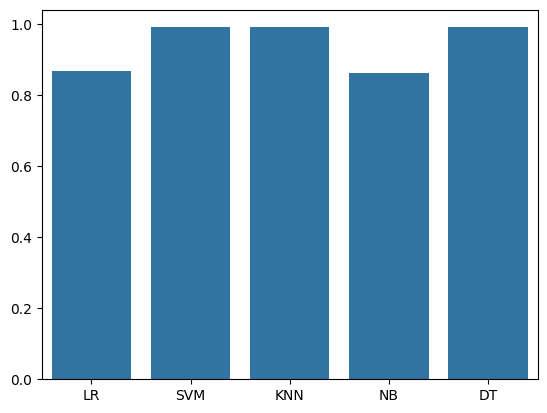

In [ ]:
from sklearn.metrics import accuracy_score

scores = {}

scores['LR'] = accuracy_score(y_test, y_lr)
scores['SVM'] = accuracy_score(y_test, y_svc)
scores['KNN'] = accuracy_score(y_test, y_knc)
scores['NB'] = accuracy_score(y_test, y_gnb)
scores['DT'] = accuracy_score(y_test, y_dtc)
scores['MY_LR'] = accuracy_score(y_test, y_my_lr)
scores['MY_SVM'] = accuracy_score(y_test, y_my_svc)

print(scores)
sns.barplot(x=list(scores.keys()), y=list(scores.values()))

NameError: name 'accuracies' is not defined

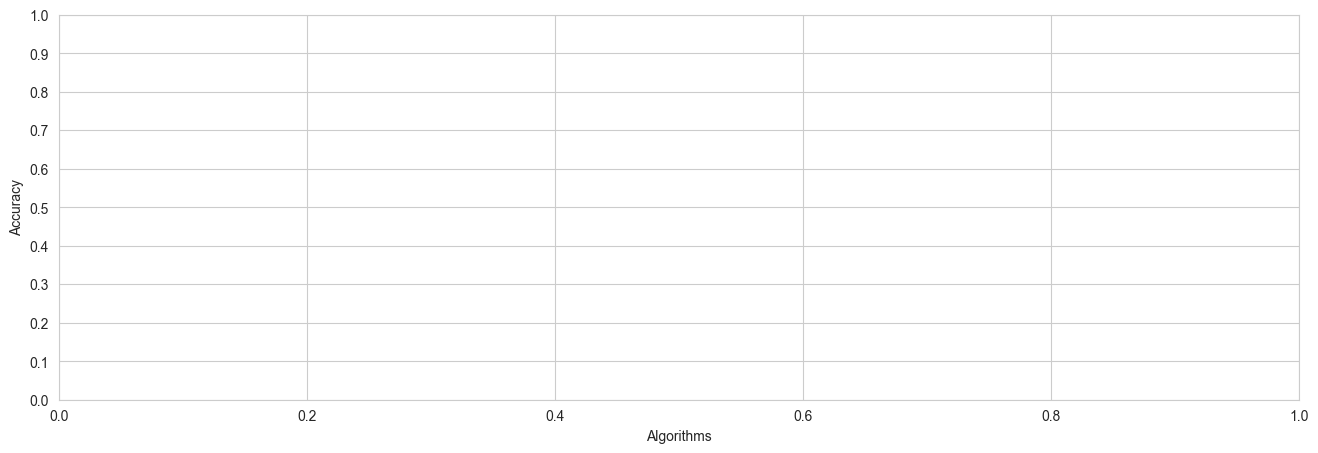

In [ ]:
# colors = ["purple", "green", "orange", "magenta", "blue"]

# sns.set_style("whitegrid")
# plt.figure(figsize=(16, 5))
# plt.yticks(np.arange(0, 1.1, 0.1))
# plt.ylabel("Accuracy")
# plt.xlabel("Algorithms")
# sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette=colors)
# plt.show()

Confusion Matrix

In [ ]:
# # Predicted values
# y_head_lr = lr.predict(X_test_scaled)
# knn3 = KNeighborsClassifier(n_neighbors = 1)
# knn3.fit(X_train_scaled, y_train)
# y_head_knn = knn3.predict(X_test_scaled)
# y_head_svm = svm.predict(X_test_scaled)
# # y_head_nb = nb.predict(X_test_scaled)
# y_head_dtc = dtc.predict(X_test)

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_lr)
cm_knn = confusion_matrix(y_test, y_knc)
cm_svm = confusion_matrix(y_test, y_svc)
cm_nb = confusion_matrix(y_test, y_gnb)
cm_dtc = confusion_matrix(y_test, y_dtc)
cm_my_lr = confusion_matrix(y_test, y_my_lr)
cm_my_svc = confusion_matrix(y_test, y_my_svc)

In [ ]:
plt.figure(figsize=(24, 12))

plt.suptitle("Confusion Matrices", fontsize=24)
plt.subplots_adjust(wspace = 0.4, hspace= 0.4)

plt.subplot(2,3,1)
plt.title("Logistic Regression Confusion Matrix")
sns.heatmap(cm_lr,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(2,3,2)
plt.title("K Nearest Neighbors Confusion Matrix")
sns.heatmap(cm_knc,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(2,3,3)
plt.title("Support Vector Machine Confusion Matrix")
sns.heatmap(cm_svm,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(2,3,4)
plt.title("Naive Bayes Confusion Matrix")
sns.heatmap(cm_gnb,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(2,3,5)
plt.title("Decision Tree Classifier Confusion Matrix")
sns.heatmap(cm_dtc,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(2,3,6)
plt.title("My Logistic Regression Confusion Matrix")
sns.heatmap(cm_my_lr,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(2,3,7)
plt.title("My support Vector Machine Confusion Matrix")
sns.heatmap(cm_my_svc,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.show()

 (**+2 балла**) Реализовать еще один из методов классификации и добавить его в сравнение.

 (**+3 балла**) Найти данные, на которых интересно будет решать задачу классификации. Повторить все пункты задания на новых данных.